<a href="https://colab.research.google.com/github/greensky0107/self_study/blob/main/Day50_DeepLearningModel_ModelBuild.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 데이터 생성

선형회귀(Linear Regression) 분석을 위한 딥러닝 모델 연습

random 으로 dataset 구성

입력 X와 정답 y로 샘플 갯수(n_samples) 200개, 특징 갯수(n_featrues) 1개에 바이어스(bias)는 5.0, 노이즈(noise)는 5.0으로 지정하고, random_state는 123으로 하여 랜덤 시드를 지정.

학습용 데이터셋(x_train, y_train), 테스트용 데이터셋(x_test, y_test) 20% 로 구분.

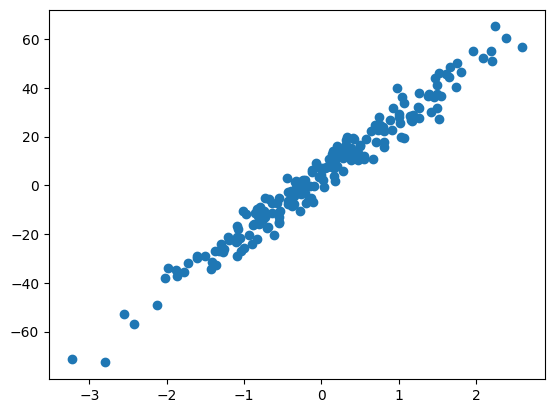

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=1,
                       bias=5.0, noise=5.0, random_state=123)
y = np.expand_dims(y, axis=1)

plt.scatter(X, y)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=123)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(160, 1) (160, 1)
(40, 1) (40, 1)


# 모델 생성

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, optimizers, utils

In [7]:
model = keras.Sequential()
model.add(layers.Dense(1, activation='linear', input_shape=(1,)))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

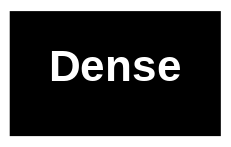

In [8]:
utils.plot_model(model)

In [9]:
optimizer = optimizers.SGD()
model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mse'])
history = model.fit(x_train, y_train, epochs=40)

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 672.6117 - mae: 21.2685 - mse: 672.6117  
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 581.8708 - mae: 19.0619 - mse: 581.8708
Epoch 3/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 454.1407 - mae: 17.4814 - mse: 454.1407 
Epoch 4/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 351.7448 - mae: 15.2693 - mse: 351.7448 
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 278.7184 - mae: 13.4476 - mse: 278.7184 
Epoch 6/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 212.0894 - mae: 11.8472 - mse: 212.0894 
Epoch 7/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 205.8060 - mae: 11.5392 - mse: 205.8060 
Epoch 8/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 144.1431 - mae: 9.3783 - mse: 144.1431
Epoch 9/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 146.4181 - mae: 9.6411 - mse: 146.4181 
Epoch 10/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 98.9447 - mae: 8.0639 - mse: 98.9447 
Epoch 11/40
5/5 ━━━━━━━━━━━━━━━━━

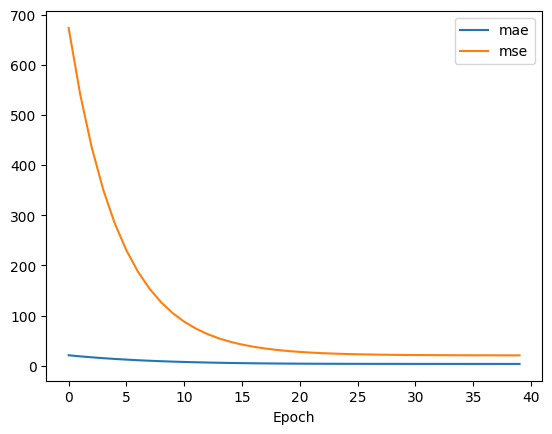

In [10]:
plt.plot(history.history['mae'])
plt.plot(history.history['mse'])
plt.xlabel('Epoch')
plt.legend(['mae', 'mse'])
plt.show();

# 모델 평가

In [11]:
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 21.7922 - mae: 3.9658 - mse: 21.7922 


[21.9493408203125, 3.9901626110076904, 21.9493408203125]

# 모델 예측

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


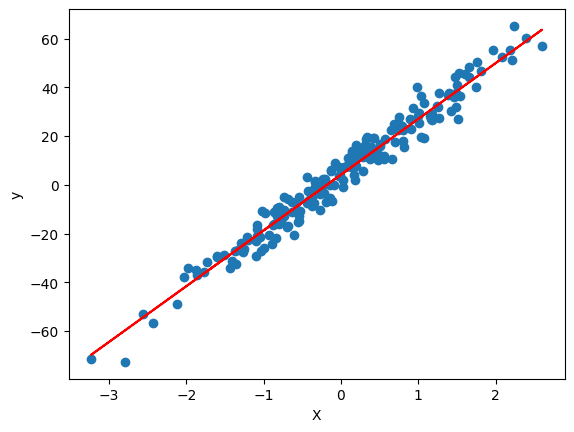

In [21]:
# 모델을 통한 data X에 대한 예측값과 실제값 y와 비교
result = model.predict(X)

plt.scatter(X, y)
plt.plot(X, result, 'r')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [22]:
# 모델에 쓰인 layer에 대한 확인
model.layers

[<Dense name=dense_1, built=True>]

In [23]:
# Layer의 이름 확인.   두가지 방법이 있음.
layer = model.layers[0]
print(layer.name)
layer = model.get_layer('dense_1')
print(layer.name)

dense_1
dense_1


In [18]:
# Layer에 사용하는 가중치(weights)와 바이어스(biases)를 get_weights() 함수를 통해서 확인

weights, biases = layer.get_weights()
print(weights)
print(biases)

[[22.887516]]
[4.176999]


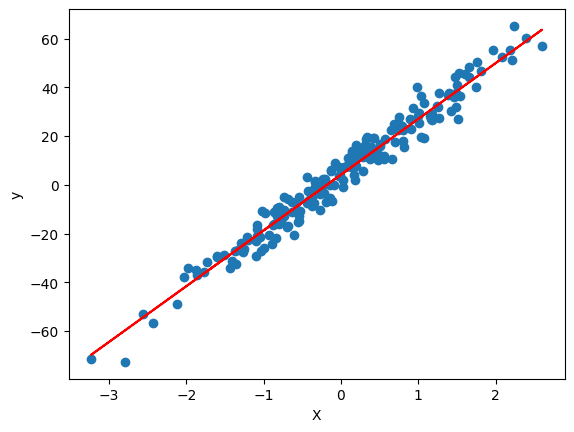

In [24]:
# 가중치(weights) 와 바이어스(biases)를 사용해서 선형회귀식을 구할 수 있음
plt.scatter(X, y)
plt.plot(X, np.array(weights * X + biases), 'r')
plt.xlabel('X')
plt.ylabel('y')
plt.show()